# 🧠 Satria Data 2025 — NLP Emotion Classification

**Dataset:** MELD (Multimodal EmotionLines Dataset)  
**Task:** Emotion Recognition dari teks percakapan  
**Emosi:** Anger, Disgust, Fear, Joy, Neutral, Sadness, Surprise (7 kelas)  

---

## Section 1: Setup Environment

In [1]:
# === Import Libraries ===
# Kaggle sudah punya semua library ini (termasuk wordcloud), tidak perlu pip install

import os
import re
import string
import warnings
import random
from collections import Counter

import numpy as np
import pandas as pd

# ML (scikit-learn) — hanya import yang benar-benar dipakai
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score
)

# Deep Learning (PyTorch)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Visualisasi — matplotlib + seaborn saja (lebih ringan dari plotly)
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
print('✅ Semua library berhasil diimport!')

✅ Semua library berhasil diimport!


In [2]:
# === Setup NLTK Data (Kaggle-compatible, no internet needed) ===

# Kaggle sudah punya NLTK data pre-installed di path ini
kaggle_nltk_paths = ['/usr/share/nltk_data', '/usr/lib/nltk_data', '/usr/local/share/nltk_data']
for p in kaggle_nltk_paths:
    if os.path.isdir(p) and p not in nltk.data.path:
        nltk.data.path.insert(0, p)

# Cek apakah data sudah ada, download hanya kalau belum
for pkg in ['punkt', 'punkt_tab', 'stopwords', 'wordnet']:
    try:
        nltk.data.find(f'tokenizers/{pkg}' if 'punkt' in pkg else f'corpora/{pkg}')
        print(f'  OK: {pkg} sudah ada')
    except LookupError:
        try:
            nltk.download(pkg, quiet=True)
            print(f'  OK: {pkg} berhasil download')
        except Exception as e:
            print(f'  SKIP: {pkg} tidak tersedia ({e})')

# Fallback: hardcoded English stopwords kalau NLTK stopwords gagal
try:
    from nltk.corpus import stopwords as _sw
    STOP_WORDS = set(_sw.words('english'))
    print(f'\nNLTK stopwords loaded ({len(STOP_WORDS)} words)')
except Exception:
    STOP_WORDS = {
        'i','me','my','myself','we','our','ours','ourselves','you',"you're","you've",
        "you'll","you'd",'your','yours','yourself','yourselves','he','him','his',
        'himself','she',"she's",'her','hers','herself','it',"it's",'its','itself',
        'they','them','their','theirs','themselves','what','which','who','whom',
        'this','that',"that'll",'these','those','am','is','are','was','were','be',
        'been','being','have','has','had','having','do','does','did','doing','a',
        'an','the','and','but','if','or','because','as','until','while','of','at',
        'by','for','with','about','against','between','through','during','before',
        'after','above','below','to','from','up','down','in','out','on','off',
        'over','under','again','further','then','once','here','there','when',
        'where','why','how','all','both','each','few','more','most','other','some',
        'such','no','nor','not','only','own','same','so','than','too','very','s',
        't','can','will','just','don',"don't",'should',"should've",'now','d','ll',
        'm','o','re','ve','y','ain','aren',"aren't",'couldn',"couldn't",'didn',
        "didn't",'doesn',"doesn't",'hadn',"hadn't",'hasn',"hasn't",'haven',
        "haven't",'isn',"isn't",'ma','mightn',"mightn't",'mustn',"mustn't",
        'needn',"needn't",'shan',"shan't",'shouldn',"shouldn't",'wasn',"wasn't",
        'weren',"weren't",'won',"won't",'wouldn',"wouldn't"
    }
    print(f'\nNLTK stopwords tidak tersedia, pakai hardcoded ({len(STOP_WORDS)} words)')

print('\nNLTK setup selesai!')


  OK: punkt sudah ada
  OK: punkt_tab sudah ada
  OK: stopwords sudah ada
  OK: wordnet berhasil download

NLTK stopwords loaded (198 words)

NLTK setup selesai!


[nltk_data] Error loading wordnet: <urlopen error [Errno -3] Temporary
[nltk_data]     failure in name resolution>


In [3]:
# === Konfigurasi Global ===

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

# Matplotlib & Seaborn style
sns.set_theme(style='whitegrid', palette='deep', font_scale=1.1)
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 100,
    'font.size': 12
})

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Label emosi MELD
EMOTION_LABELS = ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']
EMOTION_COLORS = {
    'anger': '#E74C3C', 'disgust': '#8E44AD', 'fear': '#2C3E50',
    'joy': '#F1C40F', 'neutral': '#95A5A6', 'sadness': '#3498DB',
    'surprise': '#E67E22'
}

print(f'Device : {DEVICE}' + (f' ({torch.cuda.get_device_name(0)})' if DEVICE.type == 'cuda' else ''))
print(f'Seed   : {RANDOM_SEED}')
print(f'PyTorch: {torch.__version__}')
print('✅ Konfigurasi selesai!')

Device : cpu
Seed   : 42
PyTorch: 2.10.0+cpu
✅ Konfigurasi selesai!


---

## Section 2: Data Loading

Dataset MELD sudah ditambahkan sebagai Kaggle Input (`zaber666/meld-dataset`).

In [4]:
# === Load MELD Dataset ===
# Path langsung ke CSV — lebih cepat daripada os.walk

MELD_RAW = '/kaggle/input/datasets/zaber666/meld-dataset/MELD-RAW/MELD.Raw'

# Kolom yang dibutuhkan untuk task NLP (abaikan kolom video/audio)
USE_COLS = ['Sr No.', 'Utterance', 'Speaker', 'Emotion', 'Sentiment',
            'Dialogue_ID', 'Utterance_ID', 'Season', 'Episode']

# Definisi path langsung
csv_paths = {
    'train': os.path.join(MELD_RAW, 'train', 'train_sent_emo.csv'),
    'dev':   os.path.join(MELD_RAW, 'dev_sent_emo.csv'),
    'test':  os.path.join(MELD_RAW, 'test_sent_emo.csv'),
}

# Fallback: kalau train CSV ada di level atas
if not os.path.isfile(csv_paths['train']):
    alt = os.path.join(MELD_RAW, 'train_sent_emo.csv')
    if os.path.isfile(alt):
        csv_paths['train'] = alt

# Load dengan usecols untuk hemat memory
datasets = {}
for split, path in csv_paths.items():
    if os.path.isfile(path):
        # Cek kolom yang tersedia dulu
        available_cols = pd.read_csv(path, nrows=0).columns.tolist()
        cols_to_use = [c for c in USE_COLS if c in available_cols]
        
        datasets[split] = pd.read_csv(path, usecols=cols_to_use)
        print(f'✅ {split:5s} loaded: {datasets[split].shape}  <- {os.path.basename(path)}')
    else:
        print(f'⚠️ {split:5s} NOT FOUND: {path}')

df_train = datasets.get('train')
df_dev   = datasets.get('dev')
df_test  = datasets.get('test')

if df_train is not None:
    print(f'\n--- Train Preview ---')
    display(df_train.head())
    print(f'\nKolom: {df_train.columns.tolist()}')
    print(f'Missing values:\n{df_train.isnull().sum()[df_train.isnull().sum() > 0]}')

✅ train loaded: (9989, 9)  <- train_sent_emo.csv
✅ dev   loaded: (1109, 9)  <- dev_sent_emo.csv
✅ test  loaded: (2610, 9)  <- test_sent_emo.csv

--- Train Preview ---


,Sr No.,Utterance,Speaker,Emotion,Sentiment,Dialogue_ID,Utterance_ID,Season,Episode
0,1,also I was the point person on my companys tr...,Chandler,neutral,neutral,0,0,8,21
1,2,You mustve had your hands full.,The Interviewer,neutral,neutral,0,1,8,21
2,3,That I did. That I did.,Chandler,neutral,neutral,0,2,8,21
3,4,So lets talk a little bit about your duties.,The Interviewer,neutral,neutral,0,3,8,21
4,5,My duties? All right.,Chandler,surprise,positive,0,4,8,21



Kolom: ['Sr No.', 'Utterance', 'Speaker', 'Emotion', 'Sentiment', 'Dialogue_ID', 'Utterance_ID', 'Season', 'Episode']
Missing values:
Series([], dtype: int64)


In [5]:
# === Quick Data Summary ===

for name, df in [('Train', df_train), ('Dev', df_dev), ('Test', df_test)]:
    if df is not None:
        print(f'\n📊 {name}: {len(df)} utterances, '
              f'{df["Dialogue_ID"].nunique() if "Dialogue_ID" in df.columns else "?"} dialogues')
        if 'Emotion' in df.columns:
            print(df['Emotion'].value_counts().to_string())


📊 Train: 9989 utterances, 1038 dialogues
Emotion
neutral     4710
joy         1743
surprise    1205
anger       1109
sadness      683
disgust      271
fear         268

📊 Dev: 1109 utterances, 114 dialogues
Emotion
neutral     470
joy         163
anger       153
surprise    150
sadness     111
fear         40
disgust      22

📊 Test: 2610 utterances, 280 dialogues
Emotion
neutral     1256
joy          402
anger        345
surprise     281
sadness      208
disgust       68
fear          50


In [6]:
# === Optimize dtypes untuk hemat memory ===

def optimize_df(df):
    """Downcast numeric kolom & convert string columns ke category."""
    for col in df.select_dtypes(include=['int64']).columns:
        df[col] = pd.to_numeric(df[col], downcast='integer')
    for col in df.select_dtypes(include=['float64']).columns:
        df[col] = pd.to_numeric(df[col], downcast='float')
    for col in ['Emotion', 'Sentiment', 'Speaker']:
        if col in df.columns:
            df[col] = df[col].astype('category')
    return df

for name, df in [('train', df_train), ('dev', df_dev), ('test', df_test)]:
    if df is not None:
        mem_before = df.memory_usage(deep=True).sum() / 1024**2
        optimize_df(df)
        mem_after = df.memory_usage(deep=True).sum() / 1024**2
        print(f'{name}: {mem_before:.2f} MB -> {mem_after:.2f} MB '
              f'({(1 - mem_after/mem_before)*100:.0f}% reduced)')

train: 2.86 MB -> 1.02 MB (64% reduced)
dev: 0.32 MB -> 0.11 MB (64% reduced)
test: 0.75 MB -> 0.27 MB (64% reduced)


## Section 3: Exploratory Data Analysis (EDA)

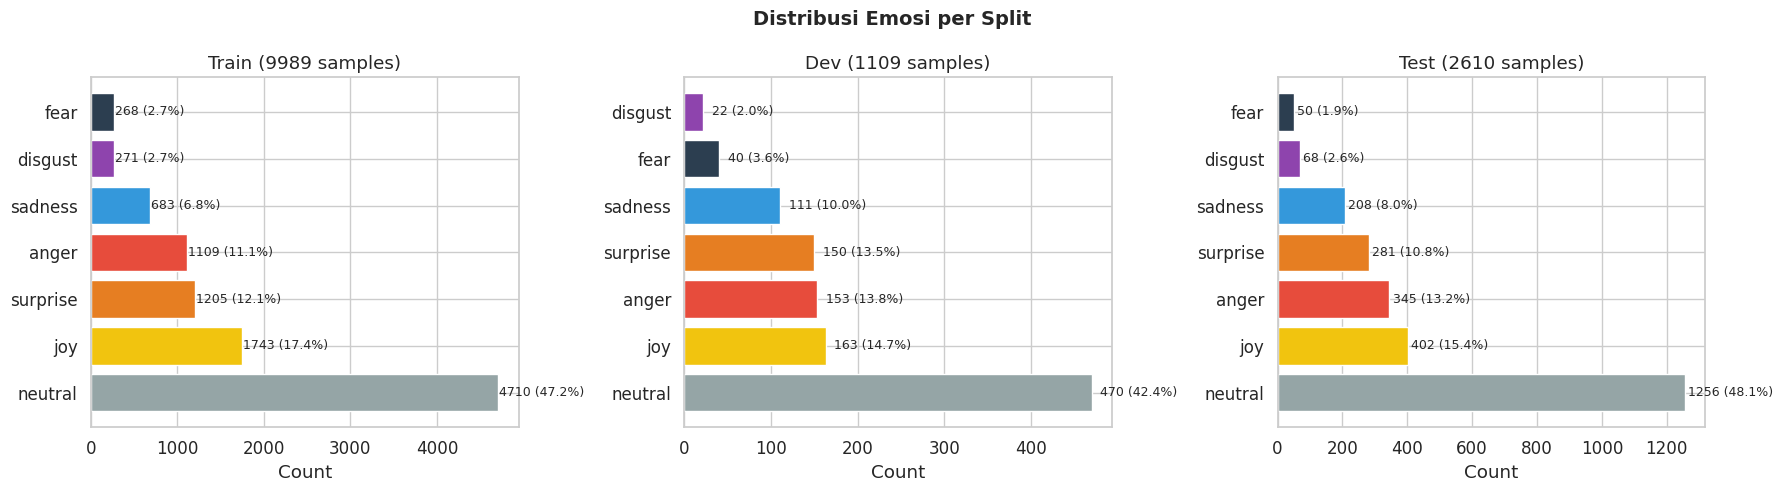

In [7]:
# === 3.1 Distribusi Emosi ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, df) in zip(axes, [('Train', df_train), ('Dev', df_dev), ('Test', df_test)]):
    if df is not None and 'Emotion' in df.columns:
        counts = df['Emotion'].value_counts()
        colors = [EMOTION_COLORS.get(e, '#999') for e in counts.index]
        ax.barh(counts.index, counts.values, color=colors)
        ax.set_title(f'{name} ({len(df)} samples)')
        ax.set_xlabel('Count')
        for i, v in enumerate(counts.values):
            ax.text(v + 10, i, f'{v} ({v/len(df)*100:.1f}%)', va='center', fontsize=9)
plt.suptitle('Distribusi Emosi per Split', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

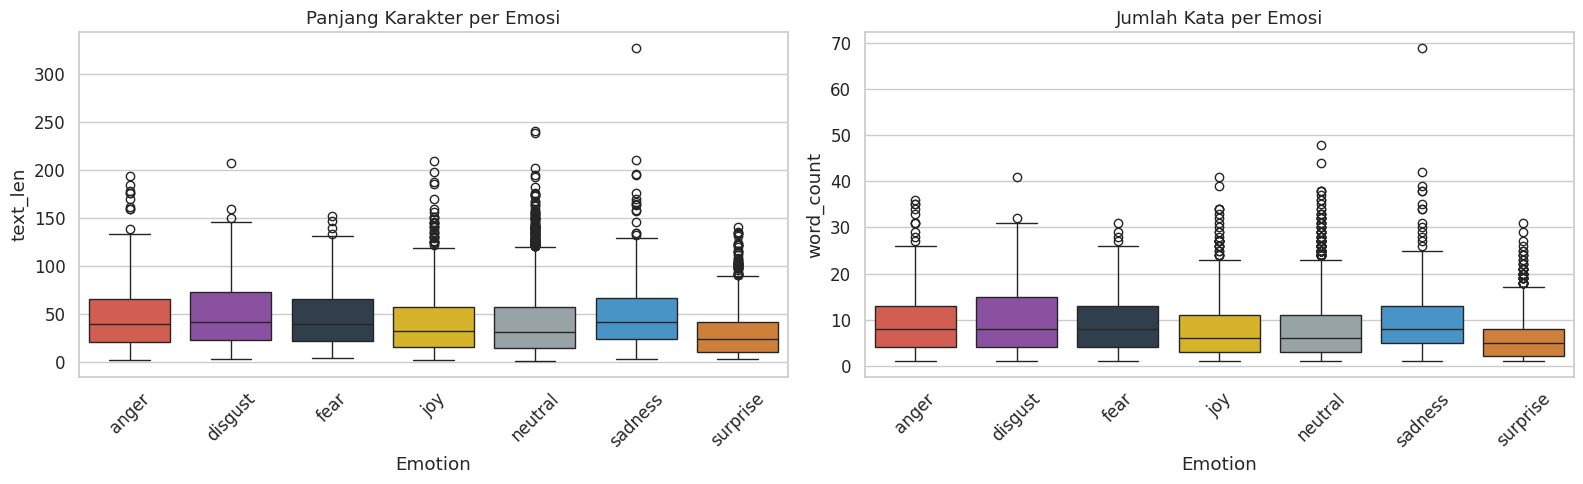

Rata-rata panjang: 8.0 kata
Max: 69 kata


In [8]:
# === 3.2 Panjang Utterance per Emosi ===
df_train['text_len'] = df_train['Utterance'].astype(str).str.len()
df_train['word_count'] = df_train['Utterance'].astype(str).str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(data=df_train, x='Emotion', y='text_len', ax=axes[0],
            palette=EMOTION_COLORS, order=EMOTION_LABELS)
axes[0].set_title('Panjang Karakter per Emosi')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df_train, x='Emotion', y='word_count', ax=axes[1],
            palette=EMOTION_COLORS, order=EMOTION_LABELS)
axes[1].set_title('Jumlah Kata per Emosi')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print(f'Rata-rata panjang: {df_train["word_count"].mean():.1f} kata')
print(f'Max: {df_train["word_count"].max()} kata')

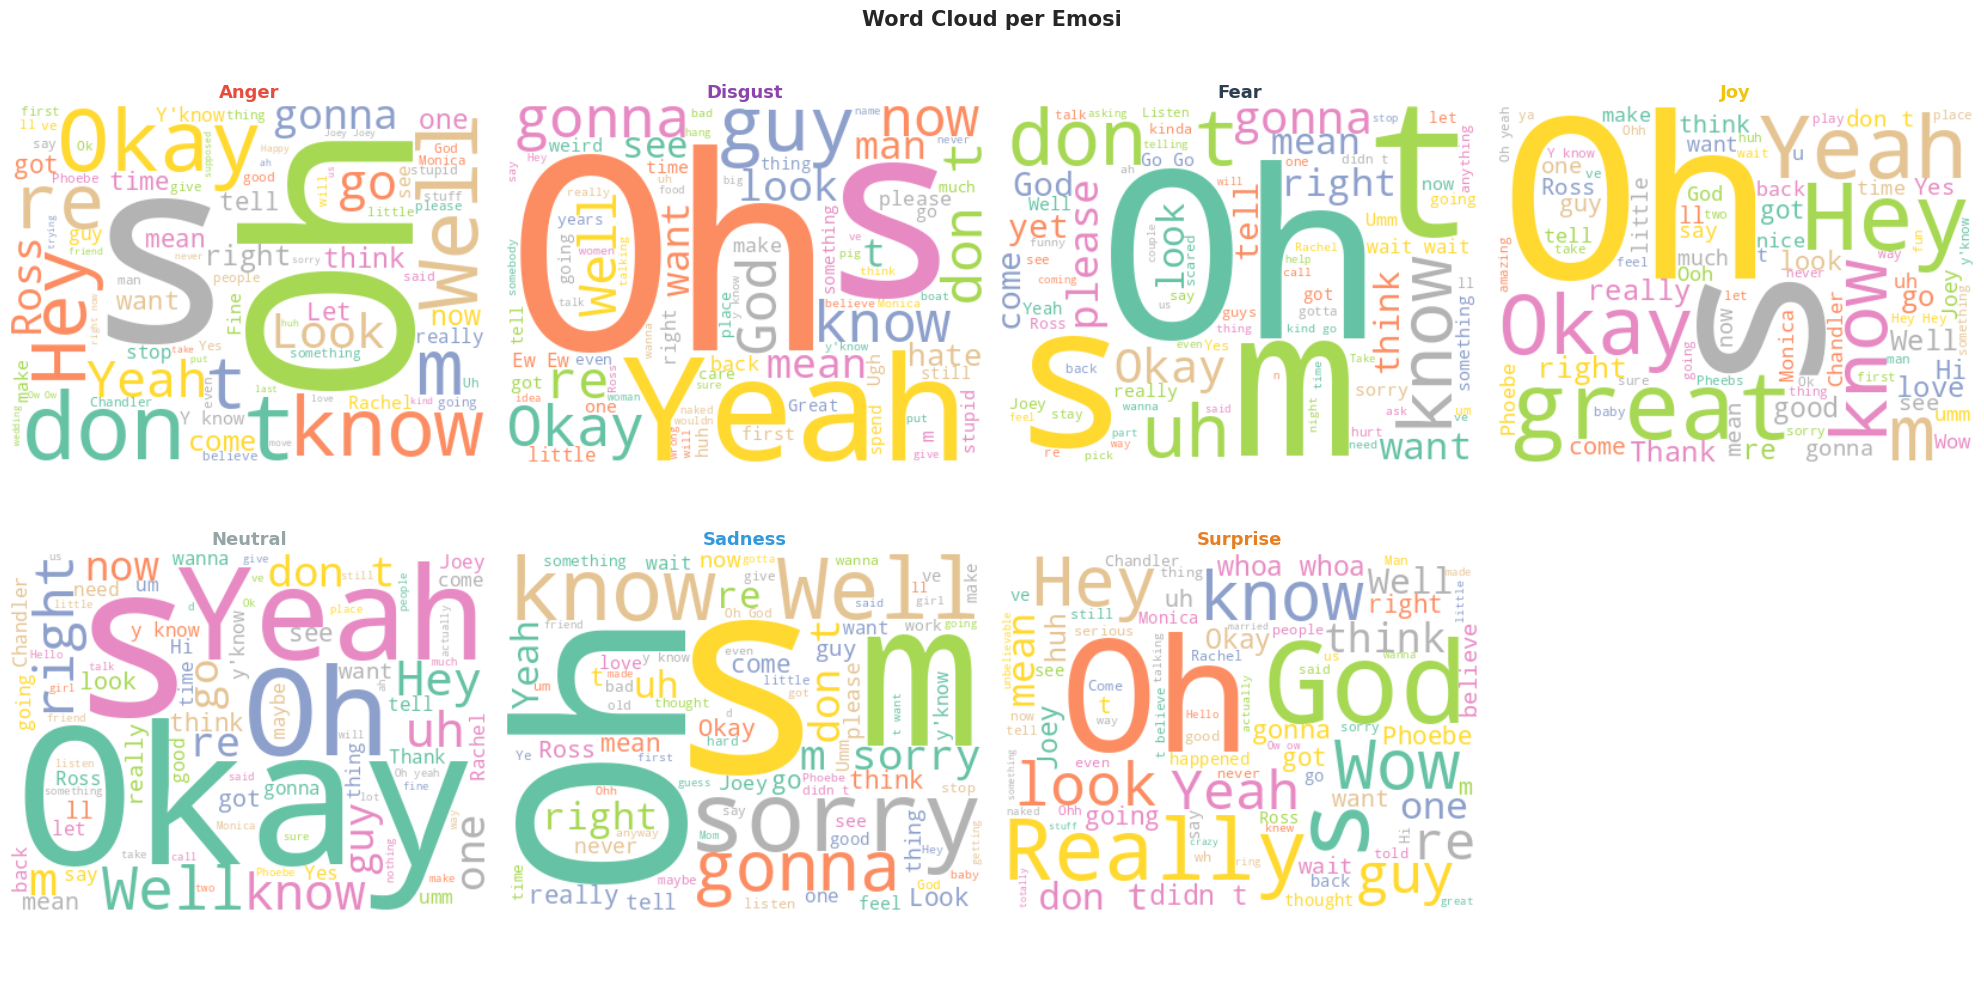

In [9]:
# === 3.3 Word Cloud per Emosi ===
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
for i, emotion in enumerate(EMOTION_LABELS):
    text = ' '.join(df_train[df_train['Emotion'] == emotion]['Utterance'].astype(str))
    wc = WordCloud(width=400, height=300, background_color='white',
                   colormap='Set2', max_words=80).generate(text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(emotion.capitalize(), fontsize=13, fontweight='bold',
                      color=EMOTION_COLORS[emotion])
    axes[i].axis('off')
axes[-1].axis('off')
plt.suptitle('Word Cloud per Emosi', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

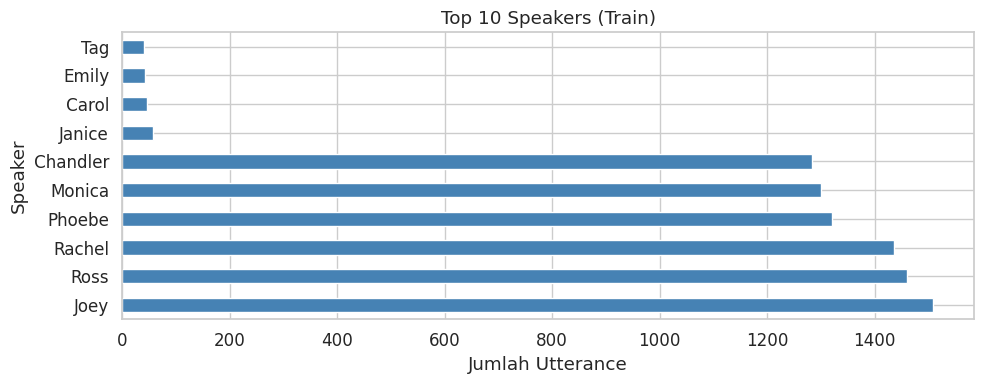

In [10]:
# === 3.4 Top Speakers ===
if 'Speaker' in df_train.columns:
    top_speakers = df_train['Speaker'].value_counts().head(10)
    fig, ax = plt.subplots(figsize=(10, 4))
    top_speakers.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title('Top 10 Speakers (Train)')
    ax.set_xlabel('Jumlah Utterance')
    plt.tight_layout()
    plt.show()

## Section 4: Text Preprocessing & Feature Engineering

In [11]:
# === 4.1 Text Cleaning ===
STOP_WORDS = set(stopwords.words('english'))

def clean_text(text):
    """Bersihkan teks: lowercase, hapus punctuation & stopwords."""
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)       # hapus URL
    text = re.sub(r'[^a-z\s]', ' ', text)              # hanya huruf
    text = re.sub(r'\s+', ' ', text).strip()           # hapus extra spaces
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 1]
    return ' '.join(tokens)

# Apply ke semua split
for df in [df_train, df_dev, df_test]:
    if df is not None:
        df['clean_text'] = df['Utterance'].apply(clean_text)

print(f'Contoh cleaning:')
for i in range(3):
    print(f'  Original : {df_train.iloc[i]["Utterance"]}')
    print(f'  Clean    : {df_train.iloc[i]["clean_text"]}\n')

Contoh cleaning:
  Original : also I was the point person on my companys transition from the KL-5 to GR-6 system.
  Clean    : also point person company transition kl gr system

  Original : You mustve had your hands full.
  Clean    : must hands full

  Original : That I did. That I did.
  Clean    : 



In [12]:
# === 4.2 Hapus empty rows setelah cleaning ===
for name, df in [('train', df_train), ('dev', df_dev), ('test', df_test)]:
    if df is not None:
        before = len(df)
        mask = df['clean_text'].str.strip().str.len() > 0
        if name == 'train':
            df_train = df[mask].reset_index(drop=True)
        elif name == 'dev':
            df_dev = df[mask].reset_index(drop=True)
        else:
            df_test = df[mask].reset_index(drop=True)
        after = len(df[mask])
        print(f'{name}: {before} -> {after} (dropped {before - after} empty)')

train: 9989 -> 9494 (dropped 495 empty)
dev: 1109 -> 1041 (dropped 68 empty)
test: 2610 -> 2486 (dropped 124 empty)


In [13]:
# === 4.3 TF-IDF Vectorization ===
tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(df_train['clean_text'])
X_dev_tfidf = tfidf.transform(df_dev['clean_text'])
X_test_tfidf = tfidf.transform(df_test['clean_text'])

# Encode labels
le = LabelEncoder()
le.fit(EMOTION_LABELS)
y_train = le.transform(df_train['Emotion'])
y_dev = le.transform(df_dev['Emotion'])
y_test = le.transform(df_test['Emotion'])

print(f'TF-IDF shape: {X_train_tfidf.shape}')
print(f'Vocabulary size: {len(tfidf.vocabulary_)}')
print(f'Labels: {le.classes_}')

TF-IDF shape: (9494, 5177)
Vocabulary size: 5177
Labels: ['anger' 'disgust' 'fear' 'joy' 'neutral' 'sadness' 'surprise']


## Section 5: Classical ML Models

In [14]:
# === 5.1 Define Models ===
models = {
    'LogisticRegression': LogisticRegression(
        C=1.0, max_iter=1000, class_weight='balanced', random_state=RANDOM_SEED, n_jobs=-1),
    'LinearSVC': LinearSVC(
        C=1.0, max_iter=2000, class_weight='balanced', random_state=RANDOM_SEED),
    'MultinomialNB': MultinomialNB(alpha=0.1),
    'RandomForest': RandomForestClassifier(
        n_estimators=200, max_depth=50, class_weight='balanced',
        random_state=RANDOM_SEED, n_jobs=-1),
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1, random_state=RANDOM_SEED),
}

# === 5.2 Train & Evaluate ===
results = {}
for name, model in tqdm(models.items(), desc='Training ML models'):
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_dev_tfidf)
    acc = accuracy_score(y_dev, y_pred)
    f1_w = f1_score(y_dev, y_pred, average='weighted')
    f1_m = f1_score(y_dev, y_pred, average='macro')
    results[name] = {'accuracy': acc, 'f1_weighted': f1_w, 'f1_macro': f1_m, 'model': model}
    print(f'{name:25s} | Acc: {acc:.4f} | F1w: {f1_w:.4f} | F1m: {f1_m:.4f}')

# Best model
best_name = max(results, key=lambda k: results[k]['f1_weighted'])
print(f'\n🏆 Best ML model: {best_name} (F1w={results[best_name]["f1_weighted"]:.4f})')

Training ML models:   0%|          | 0/5 [00:00<?, ?it/s]

LogisticRegression        | Acc: 0.3458 | F1w: 0.3639 | F1m: 0.2815
LinearSVC                 | Acc: 0.3833 | F1w: 0.3871 | F1m: 0.2914
MultinomialNB             | Acc: 0.4524 | F1w: 0.3740 | F1m: 0.2355
RandomForest              | Acc: 0.3689 | F1w: 0.3594 | F1m: 0.2597
GradientBoosting          | Acc: 0.4621 | F1w: 0.3878 | F1m: 0.2583

🏆 Best ML model: GradientBoosting (F1w=0.3878)


In [15]:
# === 5.3 Classification Report — Best ML Model ===
best_ml = results[best_name]['model']
y_pred_best = best_ml.predict(X_dev_tfidf)
print(f'Classification Report — {best_name} (Dev Set)\n')
print(classification_report(y_dev, y_pred_best, target_names=le.classes_))

Classification Report — GradientBoosting (Dev Set)

              precision    recall  f1-score   support

       anger       0.43      0.07      0.12       149
     disgust       0.14      0.10      0.11        21
        fear       0.23      0.08      0.12        37
         joy       0.44      0.20      0.28       161
     neutral       0.47      0.89      0.61       435
     sadness       0.49      0.18      0.26       106
    surprise       0.53      0.21      0.30       132

    accuracy                           0.46      1041
   macro avg       0.39      0.25      0.26      1041
weighted avg       0.45      0.46      0.39      1041



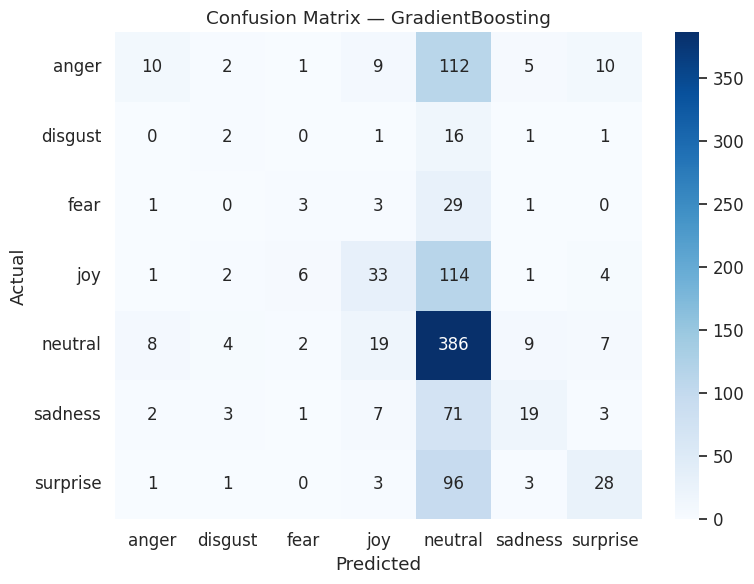

In [16]:
# === 5.4 Confusion Matrix — Best ML Model ===
cm = confusion_matrix(y_dev, y_pred_best)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {best_name}')
plt.tight_layout()
plt.show()

## Section 6: Deep Learning — BiLSTM + Attention

In [17]:
# === 6.1 Vocabulary & Dataset ===
class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=64):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        tokens = self.texts[idx].split()[:self.max_len]
        ids = [self.vocab.get(t, 1) for t in tokens]  # 1=UNK
        pad_len = self.max_len - len(ids)
        ids = ids + [0] * pad_len  # 0=PAD
        return torch.tensor(ids, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

# Build vocab from train
MAX_VOCAB = 15000
MAX_LEN = 64
word_counts = Counter()
for text in df_train['clean_text']:
    word_counts.update(text.split())
most_common = word_counts.most_common(MAX_VOCAB - 2)
vocab = {'<PAD>': 0, '<UNK>': 1}
for w, _ in most_common:
    vocab[w] = len(vocab)

BATCH_SIZE = 64
train_ds = TextDataset(df_train['clean_text'].tolist(), y_train, vocab, MAX_LEN)
dev_ds = TextDataset(df_dev['clean_text'].tolist(), y_dev, vocab, MAX_LEN)
test_ds = TextDataset(df_test['clean_text'].tolist(), y_test, vocab, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
dev_loader = DataLoader(dev_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Vocab size: {len(vocab)} | Max len: {MAX_LEN} | Batch: {BATCH_SIZE}')
print(f'Train: {len(train_ds)} | Dev: {len(dev_ds)} | Test: {len(test_ds)}')

Vocab size: 5122 | Max len: 64 | Batch: 64
Train: 9494 | Dev: 1041 | Test: 2486


In [18]:
# === 6.2 BiLSTM + Attention Model ===
class BiLSTMAttention(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=2,
                           bidirectional=True, batch_first=True, dropout=dropout)
        self.attention = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        mask = (x != 0).float().unsqueeze(-1)  # (B, L, 1)
        emb = self.dropout(self.embedding(x))
        lstm_out, _ = self.lstm(emb)             # (B, L, 2H)
        attn_w = torch.softmax(self.attention(lstm_out) + (1 - mask) * -1e9, dim=1)
        context = (lstm_out * attn_w).sum(dim=1)  # (B, 2H)
        return self.fc(self.dropout(context))

NUM_CLASSES = len(EMOTION_LABELS)
model = BiLSTMAttention(len(vocab), embed_dim=128, hidden_dim=128,
                        num_classes=NUM_CLASSES, dropout=0.3).to(DEVICE)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')
print(model)

Parameters: 1,317,128
BiLSTMAttention(
  (embedding): Embedding(5122, 128, padding_idx=0)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): Linear(in_features=256, out_features=1, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=7, bias=True)
)


In [19]:
# === 6.3 Training Loop ===
# Class weights for imbalanced data
class_counts = np.bincount(y_train, minlength=NUM_CLASSES).astype(float)
class_weights = torch.tensor(1.0 / (class_counts + 1e-6), dtype=torch.float32).to(DEVICE)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=3, factor=0.5)

NUM_EPOCHS = 20
best_f1 = 0
history = {'train_loss': [], 'dev_acc': [], 'dev_f1': []}

for epoch in range(NUM_EPOCHS):
    # Train
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)

    # Eval
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in dev_loader:
            preds = model(xb.to(DEVICE)).argmax(dim=1).cpu()
            all_preds.extend(preds.tolist())
            all_labels.extend(yb.tolist())
    dev_acc = accuracy_score(all_labels, all_preds)
    dev_f1 = f1_score(all_labels, all_preds, average='weighted')
    scheduler.step(dev_f1)

    history['train_loss'].append(avg_loss)
    history['dev_acc'].append(dev_acc)
    history['dev_f1'].append(dev_f1)

    marker = ''
    if dev_f1 > best_f1:
        best_f1 = dev_f1
        torch.save(model.state_dict(), 'best_lstm.pt')
        marker = ' ⭐'
    print(f'Epoch {epoch+1:2d}/{NUM_EPOCHS} | Loss: {avg_loss:.4f} | '
          f'Dev Acc: {dev_acc:.4f} | Dev F1w: {dev_f1:.4f}{marker}')

print(f'\n🏆 Best Dev F1 (weighted): {best_f1:.4f}')

Epoch  1/20 | Loss: 1.8843 | Dev Acc: 0.2978 | Dev F1w: 0.3142 ⭐
Epoch  2/20 | Loss: 1.7397 | Dev Acc: 0.2469 | Dev F1w: 0.2858
Epoch  3/20 | Loss: 1.5978 | Dev Acc: 0.2795 | Dev F1w: 0.3073
Epoch  4/20 | Loss: 1.4184 | Dev Acc: 0.2891 | Dev F1w: 0.3160 ⭐
Epoch  5/20 | Loss: 1.2916 | Dev Acc: 0.3228 | Dev F1w: 0.3489 ⭐
Epoch  6/20 | Loss: 1.1628 | Dev Acc: 0.3103 | Dev F1w: 0.3341
Epoch  7/20 | Loss: 1.0480 | Dev Acc: 0.3055 | Dev F1w: 0.3236
Epoch  8/20 | Loss: 0.9730 | Dev Acc: 0.3314 | Dev F1w: 0.3437
Epoch  9/20 | Loss: 0.9007 | Dev Acc: 0.3343 | Dev F1w: 0.3492 ⭐
Epoch 10/20 | Loss: 0.8419 | Dev Acc: 0.3401 | Dev F1w: 0.3559 ⭐
Epoch 11/20 | Loss: 0.7904 | Dev Acc: 0.3218 | Dev F1w: 0.3331
Epoch 12/20 | Loss: 0.7404 | Dev Acc: 0.3468 | Dev F1w: 0.3587 ⭐
Epoch 13/20 | Loss: 0.7014 | Dev Acc: 0.3449 | Dev F1w: 0.3589 ⭐
Epoch 14/20 | Loss: 0.6879 | Dev Acc: 0.3199 | Dev F1w: 0.3311
Epoch 15/20 | Loss: 0.6699 | Dev Acc: 0.3420 | Dev F1w: 0.3554
Epoch 16/20 | Loss: 0.6328 | Dev Acc: 0.3

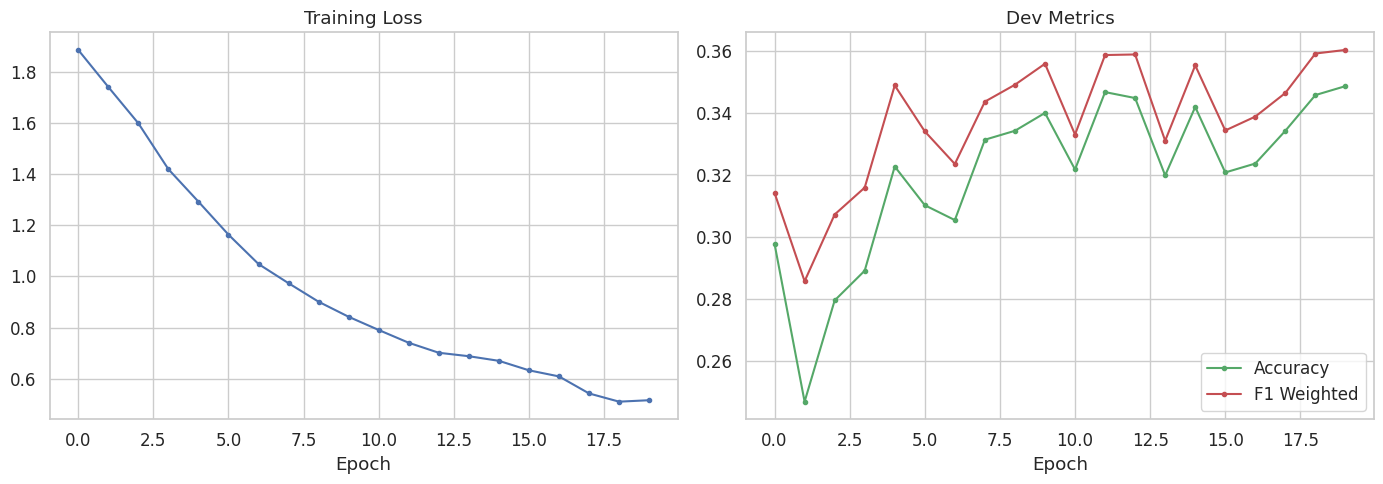

In [20]:
# === 6.4 Training Curves ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history['train_loss'], 'b-o', markersize=3)
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[1].plot(history['dev_acc'], 'g-o', markersize=3, label='Accuracy')
axes[1].plot(history['dev_f1'], 'r-o', markersize=3, label='F1 Weighted')
axes[1].set_title('Dev Metrics')
axes[1].set_xlabel('Epoch')
axes[1].legend()
plt.tight_layout()
plt.show()

## Section 7: Model Comparison & Final Results

In [21]:
# === 7.1 Load Best LSTM & Evaluate on Test Set ===
model.load_state_dict(torch.load('best_lstm.pt'))
model.eval()
lstm_preds, lstm_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        preds = model(xb.to(DEVICE)).argmax(dim=1).cpu()
        lstm_preds.extend(preds.tolist())
        lstm_labels.extend(yb.tolist())
lstm_test_acc = accuracy_score(lstm_labels, lstm_preds)
lstm_test_f1w = f1_score(lstm_labels, lstm_preds, average='weighted')
lstm_test_f1m = f1_score(lstm_labels, lstm_preds, average='macro')

# ML models on test set
comparison = []
for name, res in results.items():
    y_pred_test = res['model'].predict(X_test_tfidf)
    comparison.append({
        'Model': name,
        'Test Acc': accuracy_score(y_test, y_pred_test),
        'Test F1w': f1_score(y_test, y_pred_test, average='weighted'),
        'Test F1m': f1_score(y_test, y_pred_test, average='macro'),
    })
comparison.append({
    'Model': 'BiLSTM+Attention',
    'Test Acc': lstm_test_acc,
    'Test F1w': lstm_test_f1w,
    'Test F1m': lstm_test_f1m,
})
df_comp = pd.DataFrame(comparison).sort_values('Test F1w', ascending=False).reset_index(drop=True)
print('╔══════════════════════════════════════════════════════════╗')
print('║            FINAL MODEL COMPARISON (Test Set)            ║')
print('╚══════════════════════════════════════════════════════════╝')
display(df_comp)

╔══════════════════════════════════════════════════════════╗
║            FINAL MODEL COMPARISON (Test Set)            ║
╚══════════════════════════════════════════════════════════╝


,Model,Test Acc,Test F1w,Test F1m
0,MultinomialNB,0.518906,0.442085,0.242618
1,GradientBoosting,0.503620,0.434375,0.258213
2,RandomForest,0.433628,0.430360,0.276819
3,LinearSVC,0.412309,0.422645,0.275371
4,LogisticRegression,0.366854,0.393683,0.279780
5,BiLSTM+Attention,0.347949,0.368591,0.260193


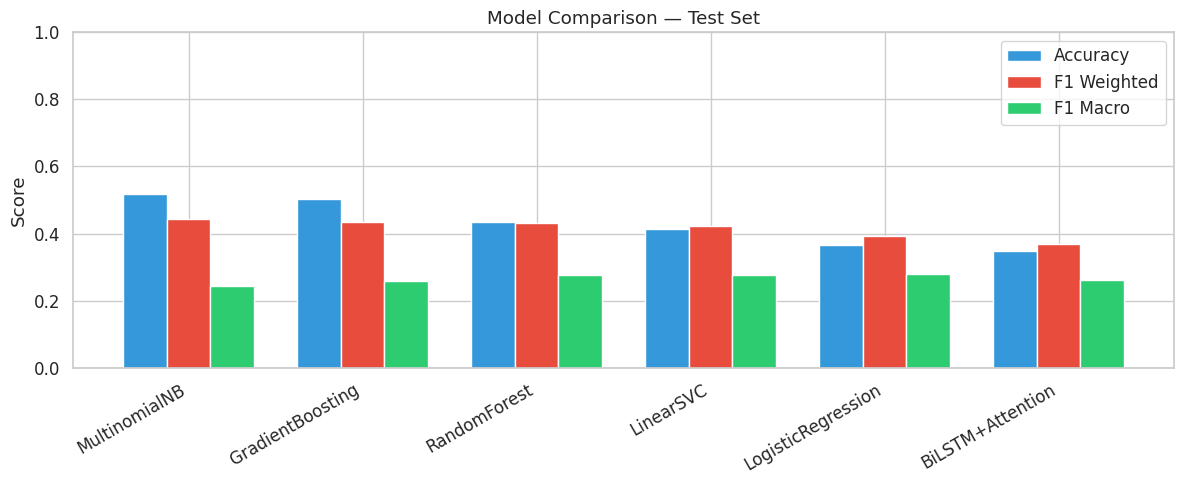


🏆 Best Overall: MultinomialNB (F1w=0.4421, Acc=0.5189)


In [22]:
# === 7.2 Visual Comparison ===
fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(df_comp))
w = 0.25
ax.bar([i - w for i in x], df_comp['Test Acc'], w, label='Accuracy', color='#3498DB')
ax.bar(x, df_comp['Test F1w'], w, label='F1 Weighted', color='#E74C3C')
ax.bar([i + w for i in x], df_comp['Test F1m'], w, label='F1 Macro', color='#2ECC71')
ax.set_xticks(x)
ax.set_xticklabels(df_comp['Model'], rotation=30, ha='right')
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Test Set')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

best_overall = df_comp.iloc[0]
print(f'\n🏆 Best Overall: {best_overall["Model"]} '
      f'(F1w={best_overall["Test F1w"]:.4f}, Acc={best_overall["Test Acc"]:.4f})')

=== Classification Report — MultinomialNB (Test Set) ===

              precision    recall  f1-score   support

       anger       0.34      0.09      0.15       335
     disgust       0.60      0.05      0.09        65
        fear       0.00      0.00      0.00        48
         joy       0.41      0.22      0.29       391
     neutral       0.54      0.90      0.68      1203
     sadness       0.34      0.08      0.14       201
    surprise       0.51      0.29      0.37       243

    accuracy                           0.52      2486
   macro avg       0.39      0.23      0.24      2486
weighted avg       0.47      0.52      0.44      2486



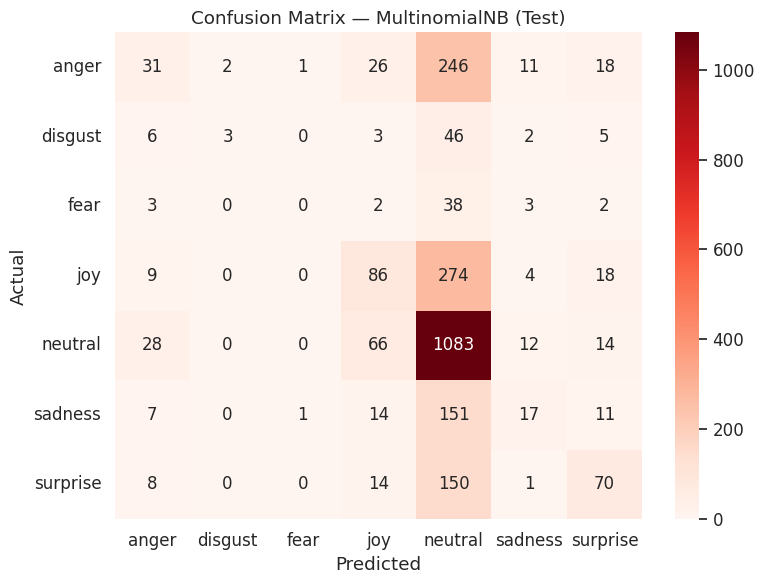

In [23]:
# === 7.3 Classification Report & Confusion Matrix — Best Overall ===
if df_comp.iloc[0]['Model'] == 'BiLSTM+Attention':
    final_preds, final_labels = lstm_preds, lstm_labels
else:
    best_ml_final = results[df_comp.iloc[0]['Model']]['model']
    final_preds = best_ml_final.predict(X_test_tfidf)
    final_labels = y_test

print(f'=== Classification Report — {df_comp.iloc[0]["Model"]} (Test Set) ===\n')
print(classification_report(final_labels, final_preds, target_names=le.classes_))

cm = confusion_matrix(final_labels, final_preds)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {df_comp.iloc[0]["Model"]} (Test)')
plt.tight_layout()
plt.show()

## Section 8: Inference Demo

In [24]:
# === 8.1 Inference Function ===
def predict_emotion(text, use_lstm=True):
    """Prediksi emosi dari teks input."""
    cleaned = clean_text(text)
    if use_lstm:
        tokens = cleaned.split()[:MAX_LEN]
        ids = [vocab.get(t, 1) for t in tokens] + [0] * (MAX_LEN - len(tokens))
        x = torch.tensor([ids[:MAX_LEN]], dtype=torch.long).to(DEVICE)
        model.eval()
        with torch.no_grad():
            logits = model(x)
            probs = torch.softmax(logits, dim=1)[0].cpu().numpy()
        pred_idx = probs.argmax()
    else:
        x = tfidf.transform([cleaned])
        pred_idx = best_ml.predict(x)[0]
        probs = None
    emotion = le.inverse_transform([pred_idx])[0]
    return emotion, probs

# === 8.2 Demo ===
test_sentences = [
    "I am so happy to see you again!",
    "This is absolutely disgusting, I can't believe it.",
    "I'm really scared of what might happen next.",
    "Whatever, I don't really care about it.",
    "How could you do this to me?! I'm furious!",
    "I feel so lonely and sad without you.",
    "Oh my god! I can't believe you're here! What a surprise!",
]

print('🎯 Emotion Prediction Demo (BiLSTM + Attention)\n')
print(f'{"Text":<55} | {"Predicted":>10} | Confidence')
print('-' * 85)
for sent in test_sentences:
    emotion, probs = predict_emotion(sent, use_lstm=True)
    conf = probs.max() if probs is not None else 0
    emoji = {'anger':'😠','disgust':'🤢','fear':'😨','joy':'😊',
             'neutral':'😐','sadness':'😢','surprise':'😲'}.get(emotion,'❓')
    print(f'{sent:<55} | {emoji} {emotion:>8} | {conf:.2%}')

🎯 Emotion Prediction Demo (BiLSTM + Attention)

Text                                                    |  Predicted | Confidence
-------------------------------------------------------------------------------------
I am so happy to see you again!                         | 😠    anger | 66.62%
This is absolutely disgusting, I can't believe it.      | 🤢  disgust | 91.73%
I'm really scared of what might happen next.            | 😲 surprise | 94.26%
Whatever, I don't really care about it.                 | 😠    anger | 58.93%
How could you do this to me?! I'm furious!              | 😨     fear | 78.15%
I feel so lonely and sad without you.                   | 😢  sadness | 99.91%
Oh my god! I can't believe you're here! What a surprise! | 😲 surprise | 82.90%


In [26]:
# === 8.3 Interactive — Coba sendiri! ===
# Ganti teks di bawah untuk test:
your_text = "I hate it when the goverment took our taxes!"
emotion, probs = predict_emotion(your_text, use_lstm=True)

print(f'Input: "{your_text}"')
print(f'Predicted Emotion: {emotion}')
if probs is not None:
    print('\nProbabilities:')
    for i, label in enumerate(le.classes_):
        bar = '█' * int(probs[i] * 40)
        print(f'  {label:10s} {probs[i]:.4f} {bar}')

Input: "I hate it when the goverment took our taxes!"
Predicted Emotion: disgust

Probabilities:
  anger      0.0096 
  disgust    0.9623 ██████████████████████████████████████
  fear       0.0212 
  joy        0.0006 
  neutral    0.0004 
  sadness    0.0032 
  surprise   0.0028 


## ✅ Notebook Selesai!**Summary:**

- Dataset MELD berhasil diproses (train/dev/test)
- 5 Classical ML models + 1 BiLSTM+Attention telah di-train
- Perbandingan model disajikan di Section 7- Inference demo tersedia di Section 8